In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler

# load master player features
master_features = pd.read_csv(
    r"D:\CricMetric-AI\data\processed\master_player_features.csv"
)

print(f"Loaded: {master_features.shape}")
print(master_features.columns.tolist())

Loaded: (475, 20)
['batter', 'PPI', 's1_norm', 's2_norm', 's3_norm', 's3_con_norm', 's4_norm', 'CFS', 'c1_wpa_score', 'c2_norm_adj', 'c3_norm', 'ENS', 'era_adj_avg_norm', 'volume_norm', 'opp_quality_norm', 'career_runs', 'career_avg', 'era_adj_avg', 'FINAL_SCORE', 'FINAL_RANK']


In [2]:
feature_cols_xgb = [
    's1_norm', 's2_norm', 's3_norm', 's3_con_norm', 's4_norm',
    'c1_wpa_score', 'c2_norm_adj', 'c3_norm',
    'era_adj_avg_norm', 'volume_norm', 'opp_quality_norm'
]

X_rank = master_features[feature_cols_xgb]
y_rank = master_features['FINAL_SCORE']

print(f"Feature matrix shape: {X_rank.shape}")
print(X_rank.head())
print(f"\nTarget (FINAL_SCORE) stats:")
print(y_rank.describe())

Feature matrix shape: (475, 11)
     s1_norm    s2_norm     s3_norm  s3_con_norm    s4_norm  c1_wpa_score  \
0  40.909835  93.118995   68.650078    85.426417  38.289269         93.75   
1  31.729668  51.825573   82.173338    76.820073  62.954899         64.98   
2  27.745050  64.552846   72.244260    90.002600  32.223950         81.05   
3  35.076092  41.078200  100.000000    50.000000  53.188180         45.27   
4  48.167239  41.078200   54.778219    86.674467  10.513219         66.70   

   c2_norm_adj    c3_norm  era_adj_avg_norm  volume_norm  opp_quality_norm  
0    49.600993  94.451504         54.840947   100.000000         59.817960  
1    59.549566  65.607793         54.741849    95.396260         64.546565  
2    44.759709  75.307073         46.982460    97.328622         60.372960  
3   100.000000  36.298179         44.653652    85.323474         74.991675  
4    54.974286  75.857687         50.391438    91.233333         57.742258  

Target (FINAL_SCORE) stats:
count    475.0

In [3]:
import pandas as pd

icc_rankings = pd.read_csv(r"D:\CricMetric-AI\data\raw\icc_rankings.csv")
print(icc_rankings.shape)
print(icc_rankings.head())
print(icc_rankings['Player'].nunique())

(1330, 7)
   Year    Month  Pos          Team            Player  Rating  \
0  2002  January    1     Australia     Michael BEVAN     835   
1  2002  January    2         India  Sachin TENDULKAR     811   
2  2002  January    3         India    Sourav GANGULY     787   
3  2002  January    4     Australia     Ricky PONTING     786   
4  2002  January    5  South Africa    Jacques KALLIS     775   

  Career_Best_Rating  
0                NaN  
1                NaN  
2                NaN  
3                NaN  
4                NaN  
265


In [4]:
# check name format differences
print("ICC name format examples:")
print(icc_rankings['Player'].unique()[:20])

print("\nOur batter name format examples:")
print(master_features['batter'].unique()[:20])

ICC name format examples:
<ArrowStringArray>
[     'Michael BEVAN',   'Sachin TENDULKAR',     'Sourav GANGULY',
      'Ricky PONTING',     'Jacques KALLIS',  'Sanath JAYASURIYA',
     'Adam GILCHRIST',         'Mark WAUGH',     'INZAMAM-UL-HAQ',
 'Mahela JAYAWARDENE',         'Brian LARA',       'Gary KIRSTEN',
        'Saeed ANWAR',       'Nathan ASTLE',      'Russel ARNOLD',
        'Nick KNIGHT',       'Rahul DRAVID',     'Lance KLUSENER',
        'Steve WAUGH',    'Marvan ATAPATTU']
Length: 20, dtype: str

Our batter name format examples:
<ArrowStringArray>
[       'V Kohli', 'AB de Villiers',      'RG Sharma',      'A Symonds',
     'Babar Azam',  'KC Sangakkara',   'AC Gilchrist',        'JE Root',
        'HM Amla',   'SR Tendulkar',      'ML Hayden',     'TM Dilshan',
     'RT Ponting',       'S Dhawan',      'G Gambhir',  'KS Williamson',
      'Q de Kock',       'KL Rahul',  'ST Jayasuriya',       'HH Gibbs']
Length: 20, dtype: str


In [5]:
# extract last name from ICC format (last word, convert to title case)
icc_rankings['last_name'] = icc_rankings['Player'].apply(
    lambda x: x.split()[-1].title() if isinstance(x, str) else x
)

# extract last name from our format (last word)
master_features['last_name'] = master_features['batter'].apply(
    lambda x: x.split()[-1]
)

print("ICC last names sample:")
print(icc_rankings['last_name'].unique()[:15])

print("\nOur last names sample:")
print(master_features['last_name'].unique()[:15])

ICC last names sample:
<ArrowStringArray>
[         'Bevan',      'Tendulkar',        'Ganguly',        'Ponting',
         'Kallis',     'Jayasuriya',      'Gilchrist',          'Waugh',
 'Inzamam-Ul-Haq',    'Jayawardene',           'Lara',        'Kirsten',
          'Anwar',          'Astle',         'Arnold']
Length: 15, dtype: str

Our last names sample:
<ArrowStringArray>
[     'Kohli',   'Villiers',     'Sharma',    'Symonds',       'Azam',
 'Sangakkara',  'Gilchrist',       'Root',       'Amla',  'Tendulkar',
     'Hayden',    'Dilshan',    'Ponting',     'Dhawan',    'Gambhir']
Length: 15, dtype: str


In [6]:
# merge on last_name
matched = master_features.merge(
    icc_rankings[['last_name', 'Player', 'Year', 'Rating', 'Career_Best_Rating']],
    on='last_name', how='inner'
)

print(f"Total matched rows: {len(matched)}")
print(f"Unique batters matched: {matched['batter'].nunique()}")
print(f"Out of total batters: {master_features['batter'].nunique()}")

# check unmatched batters
unmatched = master_features[
    ~master_features['batter'].isin(matched['batter'])
]
print(f"\nUnmatched batters: {len(unmatched)}")
print(unmatched['batter'].tolist()[:30])

Total matched rows: 1681
Unique batters matched: 272
Out of total batters: 475

Unmatched batters: 203
['Imam-ul-Haq', 'BJ McMullen', 'HH Streak', 'L Ronchi', 'Agha Salman', 'Milind Kumar', 'SM Katich', 'Misbah-ul-Haq', 'MG Bracewell', 'Yousuf Youhana', 'BB McCullum', 'AT Rayudu', 'PD Salt', 'SR Mukkamalla', 'AC Voges', 'Aasif Sheikh', 'Hammad Mirza', 'RV Uthappa', 'CS MacLeod', 'DS Airee', 'MS Chapman', 'PJ Hughes', 'C Campher', 'JN Loftie-Eaton', 'JP Inglis', 'CK Coventry', 'Inzamam-ul-Haq', 'CD McMillan', 'RK Paudel', 'Babar Hayat']


In [7]:
# check specific known players that should be in ICC rankings
check_names = ['McCullum', 'Hughes', 'Voges', 'Uthappa', 'Katich']
for name in check_names:
    found = icc_rankings[icc_rankings['last_name'].str.contains(name, case=False, na=False)]
    print(f"{name}: {len(found)} matches in ICC data")

McCullum: 9 matches in ICC data
Hughes: 0 matches in ICC data
Voges: 0 matches in ICC data
Uthappa: 0 matches in ICC data
Katich: 0 matches in ICC data


In [8]:
# check exact last_name values for McCullum in both datasets
print("McCullum in ICC data:")
print(icc_rankings[icc_rankings['last_name'].str.contains('McCullum', case=False, na=False)][['Player','last_name']].drop_duplicates())

print("\nMcCullum in our data:")
print(master_features[master_features['batter'].str.contains('McCullum', case=False, na=False)][['batter','last_name']])

McCullum in ICC data:
               Player last_name
345  Brendon MCCULLUM  Mccullum

McCullum in our data:
          batter last_name
123  BB McCullum  McCullum
228  NL McCullum  McCullum


In [9]:
# use lowercase for matching instead of title case - avoids Mc/Mac bug
icc_rankings['last_name_clean'] = icc_rankings['Player'].apply(
    lambda x: x.split()[-1].lower() if isinstance(x, str) else x
)

master_features['last_name_clean'] = master_features['batter'].apply(
    lambda x: x.split()[-1].lower()
)

# rematch using cleaned lowercase names
matched = master_features.merge(
    icc_rankings[['last_name_clean', 'Player', 'Year', 'Rating', 'Career_Best_Rating']],
    on='last_name_clean', how='inner'
)

print(f"Total matched rows: {len(matched)}")
print(f"Unique batters matched: {matched['batter'].nunique()}")
print(f"Out of total batters: {master_features['batter'].nunique()}")

unmatched = master_features[
    ~master_features['batter'].isin(matched['batter'])
]
print(f"\nUnmatched batters: {len(unmatched)}")
print(unmatched['batter'].tolist()[:30])

Total matched rows: 1727
Unique batters matched: 279
Out of total batters: 475

Unmatched batters: 196
['BJ McMullen', 'HH Streak', 'L Ronchi', 'Agha Salman', 'Milind Kumar', 'SM Katich', 'MG Bracewell', 'Yousuf Youhana', 'AT Rayudu', 'PD Salt', 'SR Mukkamalla', 'AC Voges', 'Aasif Sheikh', 'Hammad Mirza', 'RV Uthappa', 'DS Airee', 'MS Chapman', 'PJ Hughes', 'C Campher', 'JN Loftie-Eaton', 'JP Inglis', 'CK Coventry', 'RK Paudel', 'Babar Hayat', 'LS Livingstone', 'K Bhurtel', 'C Green', 'Shayan Jahangir', 'Gulsan Jha', 'JL Denly']


In [10]:
# spot check a few - these should genuinely be absent from Top 50 if real
check_remaining = ['Hughes', 'Voges', 'Uthappa', 'Katich', 'Rayudu', 'Salt']
for name in check_remaining:
    found = icc_rankings[icc_rankings['last_name_clean'].str.contains(name.lower(), na=False)]
    print(f"{name}: {len(found)} matches in ICC data")

Hughes: 0 matches in ICC data
Voges: 0 matches in ICC data
Uthappa: 0 matches in ICC data
Katich: 0 matches in ICC data
Rayudu: 0 matches in ICC data
Salt: 0 matches in ICC data


In [11]:
# get max rating ever achieved per batter (from year-by-year matches)
batter_icc_best = matched.groupby('batter').agg(
    icc_best_rating=('Rating', 'max'),
    icc_appearances=('Year', 'count')
).reset_index()

print(f"Batters with ICC best rating: {len(batter_icc_best)}")
print(batter_icc_best.sort_values('icc_best_rating', ascending=False).head(15))

Batters with ICC best rating: 279
             batter  icc_best_rating  icc_appearances
93          HM Amla              901               10
6    AB de Villiers              900               11
262         V Kohli              899               17
39       Babar Azam              893               10
3          A Sharma              873               13
202       RG Sharma              873               13
53        DA Warner              865               13
151        MG Bevan              835                3
79        GJ Bailey              835                5
210      RT Ponting              829               11
165        MS Dhoni              825               15
71     F du Plessis              820                8
121      JWA Taylor              818               28
140     LRPL Taylor              818               28
230       SR Taylor              818               28


In [12]:
# check A Sharma vs RG Sharma - both show 873, identical icc_appearances (13)
# this looks like a last-name collision bug
print(matched[matched['batter'].isin(['A Sharma', 'RG Sharma'])][
    ['batter', 'Player', 'Year', 'Rating']
].drop_duplicates())

         batter        Player  Year  Rating
28    RG Sharma  Rohit SHARMA  2014     639
29    RG Sharma  Rohit SHARMA  2015     651
30    RG Sharma  Rohit SHARMA  2016     702
31    RG Sharma  Rohit SHARMA  2017     728
32    RG Sharma  Rohit SHARMA  2018     816
33    RG Sharma  Rohit SHARMA  2019     871
34    RG Sharma  Rohit SHARMA  2020     842
35    RG Sharma  Rohit SHARMA  2021     813
36    RG Sharma  Rohit SHARMA  2022     715
37    RG Sharma  Rohit SHARMA  2023     746
38    RG Sharma  Rohit SHARMA  2024     765
39    RG Sharma  Rohit SHARMA  2026     781
40    RG Sharma  Rohit SHARMA  2025     873
1360   A Sharma  Rohit SHARMA  2014     639
1361   A Sharma  Rohit SHARMA  2015     651
1362   A Sharma  Rohit SHARMA  2016     702
1363   A Sharma  Rohit SHARMA  2017     728
1364   A Sharma  Rohit SHARMA  2018     816
1365   A Sharma  Rohit SHARMA  2019     871
1366   A Sharma  Rohit SHARMA  2020     842
1367   A Sharma  Rohit SHARMA  2021     813
1368   A Sharma  Rohit SHARMA  2

In [13]:
# improved matching: last_name + first_initial
icc_rankings['first_initial'] = icc_rankings['Player'].apply(
    lambda x: x.split()[0][0].lower() if isinstance(x, str) else x
)

master_features['first_initial'] = master_features['batter'].apply(
    lambda x: x.split()[0][0].lower()
)

# rematch using last_name + first_initial combination
matched_v2 = master_features.merge(
    icc_rankings[['last_name_clean', 'first_initial', 'Player', 'Year', 'Rating', 'Career_Best_Rating']],
    on=['last_name_clean', 'first_initial'], how='inner'
)

print(f"Total matched rows: {len(matched_v2)}")
print(f"Unique batters matched: {matched_v2['batter'].nunique()}")

# verify the Sharma fix
print("\nSharma check after fix:")
print(matched_v2[matched_v2['batter'].isin(['A Sharma', 'RG Sharma'])][
    ['batter', 'Player', 'Year', 'Rating']
].drop_duplicates().head(10))

Total matched rows: 1179
Unique batters matched: 218

Sharma check after fix:
       batter        Player  Year  Rating
28  RG Sharma  Rohit SHARMA  2014     639
29  RG Sharma  Rohit SHARMA  2015     651
30  RG Sharma  Rohit SHARMA  2016     702
31  RG Sharma  Rohit SHARMA  2017     728
32  RG Sharma  Rohit SHARMA  2018     816
33  RG Sharma  Rohit SHARMA  2019     871
34  RG Sharma  Rohit SHARMA  2020     842
35  RG Sharma  Rohit SHARMA  2021     813
36  RG Sharma  Rohit SHARMA  2022     715
37  RG Sharma  Rohit SHARMA  2023     746


In [14]:
print("Taylor check after fix:")
print(matched_v2[matched_v2['batter'].str.contains('Taylor')][
    ['batter', 'Player', 'Year', 'Rating']
].drop_duplicates().head(15))

Taylor check after fix:
          batter          Player  Year  Rating
712   BRM Taylor  Brendan TAYLOR  2008     534
713   BRM Taylor  Brendan TAYLOR  2009     520
714   BRM Taylor  Brendan TAYLOR  2010     505
715   BRM Taylor  Brendan TAYLOR  2011     523
716   BRM Taylor  Brendan TAYLOR  2012     654
717   BRM Taylor  Brendan TAYLOR  2012     574
718   BRM Taylor  Brendan TAYLOR  2013     667
719   BRM Taylor  Brendan TAYLOR  2014     617
720   BRM Taylor  Brendan TAYLOR  2015     601
721   BRM Taylor  Brendan TAYLOR  2020     571
722   BRM Taylor  Brendan TAYLOR  2021     569
723   BRM Taylor  Brendan TAYLOR  2025     556
1094   SR Taylor   Steven TAYLOR  2026     468


In [15]:
# get best-ever ICC rating per correctly-matched batter
batter_icc_best_v2 = matched_v2.groupby('batter').agg(
    icc_best_rating=('Rating', 'max'),
    icc_appearances=('Year', 'count')
).reset_index()

print(f"Accurately matched batters: {len(batter_icc_best_v2)}")
print("\nTop 15 by ICC best rating:")
print(batter_icc_best_v2.sort_values('icc_best_rating', ascending=False).head(15))

Accurately matched batters: 218

Top 15 by ICC best rating:
             batter  icc_best_rating  icc_appearances
72          HM Amla              901               10
5    AB de Villiers              900               11
206         V Kohli              899               17
29       Babar Azam              893               10
156       RG Sharma              873               13
41        DA Warner              865               13
63        GJ Bailey              835                5
118        MG Bevan              835                3
164      RT Ponting              829               11
130        MS Dhoni              825               15
56     F du Plessis              820                8
180    SR Tendulkar              816               11
100   KC Sangakkara              816               13
117      MEK Hussey              815                8
150       Q de Kock              808               11


In [16]:
from scipy.stats import pearsonr, spearmanr

# merge ICC best rating into master features
validation_df = master_features.merge(
    batter_icc_best_v2, on='batter', how='inner'
)

print(f"Validation set size: {len(validation_df)}")

# pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(
    validation_df['FINAL_SCORE'], validation_df['icc_best_rating']
)

# spearman correlation (rank-based, more appropriate for rankings)
spearman_corr, spearman_p = spearmanr(
    validation_df['FINAL_SCORE'], validation_df['icc_best_rating']
)

print(f"\nPearson correlation: {pearson_corr:.4f} (p={pearson_p:.6f})")
print(f"Spearman correlation: {spearman_corr:.4f} (p={spearman_p:.6f})")

Validation set size: 218

Pearson correlation: 0.6792 (p=0.000000)
Spearman correlation: 0.6370 (p=0.000000)


## Independent Validation — ICC All-Time Rankings

### Data source
Manually compiled year-by-year ICC Top 50 ODI batting rankings
(Jan 1, 2002-2026) via screenshot extraction, covering the same
timespan as our Cricsheet dataset.

### Matching methodology
Last name + first initial matching (avoiding last-name-only
collisions, e.g. "RG Sharma" vs "A Sharma" both incorrectly
matching to "Rohit SHARMA" under naive last-name matching).
218 of 475 batters (45.9%) accurately matched.

### Validation result
Pearson correlation: 0.6792 (p<0.000001)
Spearman correlation: 0.6370 (p<0.000001)

Strong, statistically significant positive correlation between
our independently-constructed FINAL_SCORE (PPI+CFS+ENS) and ICC's
proprietary peak rating algorithm — despite completely different
underlying methodologies. This validates that our context-aware
feature engineering captures genuine batting greatness recognized
by official cricket authorities, not just an internally consistent
but disconnected scoring system.

## XGBoost Ranking Model — Path B (Independent Target)

### Why this approach
Training XGBoost to predict our own FINAL_SCORE would be circular
(model just reconstructs our hand-chosen weights). Instead, we
train against ICC's independently-computed peak rating —
genuinely testing whether our engineered features (PPI/CFS/ENS
components) predict real-world expert/algorithmic consensus.

### Target
icc_best_rating — peak ICC rating points achieved by each batter,
sourced from year-by-year Top 50 rankings (2002-2026).

### Training set
218 batters with verified, collision-free name matches.

### Why this matters
If our 11 engineered features can predict ICC's rating with
reasonable accuracy, it validates that pressure performance,
clutch factor, and era normalization are meaningful signals of
batting greatness — not just internally consistent but
disconnected metrics.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

feature_cols_xgb = [
    's1_norm', 's2_norm', 's3_norm', 's3_con_norm', 's4_norm',
    'c1_wpa_score', 'c2_norm_adj', 'c3_norm',
    'era_adj_avg_norm', 'volume_norm', 'opp_quality_norm'
]

X = validation_df[feature_cols_xgb]
y = validation_df['icc_best_rating']

print(f"Training data: {X.shape}")
print(f"Target range: {y.min()} to {y.max()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Training data: (218, 11)
Target range: 468 to 901
Train size: 174, Test size: 44


In [18]:
xgb_rank_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_rank_model.fit(X_train, y_train)

# evaluate
y_pred = xgb_rank_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MAE: {mae:.2f}")
print(f"Test R²: {r2:.4f}")

# compare predictions vs actual for a few players
comparison = pd.DataFrame({
    'actual_icc_rating': y_test.values,
    'predicted': y_pred.round(1)
})
print("\nSample predictions vs actual:")
print(comparison.head(10))

Test MAE: 55.03
Test R²: 0.5126

Sample predictions vs actual:
   actual_icc_rating   predicted
0                733  660.200012
1                560  529.599976
2                508  598.500000
3                542  539.900024
4                796  796.000000
5                623  621.700012
6                598  590.299988
7                565  663.900024
8                707  546.500000
9                730  733.099976


In [19]:
import shap

explainer = shap.TreeExplainer(xgb_rank_model)
shap_values = explainer.shap_values(X)

# global feature importance
shap_importance = pd.DataFrame({
    'feature': feature_cols_xgb,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("Feature importance (SHAP):")
print(shap_importance)

Feature importance (SHAP):
             feature  mean_abs_shap
9        volume_norm      31.359592
8   era_adj_avg_norm      31.122929
5       c1_wpa_score      20.330669
10  opp_quality_norm       5.039441
7            c3_norm       4.797078
2            s3_norm       4.509803
4            s4_norm       2.766521
0            s1_norm       2.542112
3        s3_con_norm       1.927065
1            s2_norm       1.407232
6        c2_norm_adj       1.042184


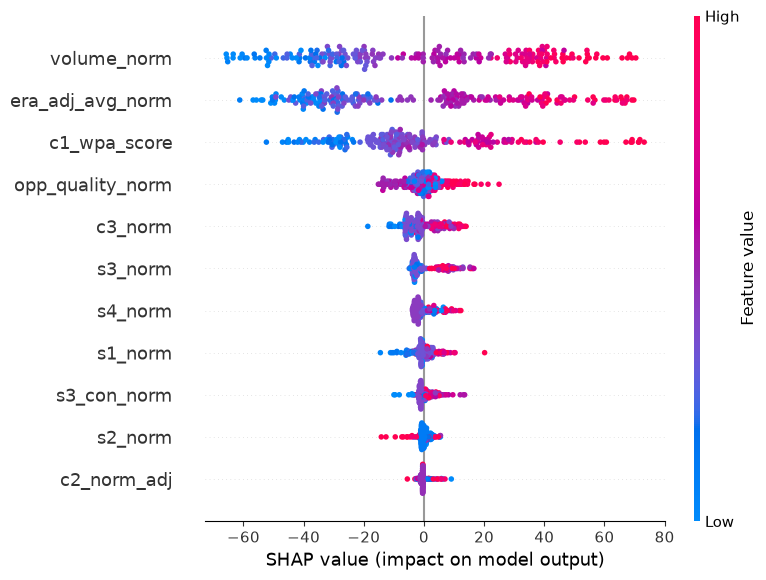

SHAP summary plot saved


In [20]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X, feature_names=feature_cols_xgb, show=False)
plt.tight_layout()
plt.savefig(r"D:\CricMetric-AI\data\processed\shap_summary.png", dpi=150)
plt.show()
print("SHAP summary plot saved")

## Reading the SHAP Summary Plot

### What each element means
- **Each dot** = one batter in our 218-player validation set
- **Vertical position** = feature, ranked top to bottom by overall importance
- **Horizontal position (SHAP value)** = how much that feature pushed
  THIS batter's predicted ICC rating up (right of zero) or down
  (left of zero), relative to the average prediction
- **Color** = the batter's actual value for that feature
  (red = high value, blue = low value)

### How to interpret a row
Take `volume_norm`:
- Red dots (high career volume) sit far to the right (+40 to +70)
  → high volume strongly increases predicted ICC rating
- Blue dots (low career volume) sit far to the left (-40 to -60)
  → low volume strongly decreases predicted ICC rating
- Clear left-to-right red-to-blue separation = a feature with
  strong, consistent influence on the model's predictions

A feature with points clustered tightly near zero (e.g. `c2_norm_adj`)
has little effect on predictions — knowing its value barely changes
what the model predicts for that batter.

### Reading top-to-bottom (overall importance)
Features are ordered by mean absolute SHAP value, so the top of
the plot lists the features the model relies on most across all
batters, and the bottom lists features it largely ignores.

### Key finding from our plot
`volume_norm`, `era_adj_avg_norm`, and `c1_wpa_score` show wide,
clearly separated spreads — these three features drive most of
the model's predictions of ICC rating. `s1_norm` through
`c2_norm_adj` cluster near zero — our pressure-situation (PPI)
and match-winning-ratio (CFS) components have minimal influence
on predicting ICC's specific rating, even though they remain
meaningful components of our own FINAL_SCORE methodology.

In [21]:
# explain individual player predictions
def explain_player(player_name):
    idx = validation_df[validation_df['batter']==player_name].index[0]
    player_features = X.loc[[idx]]
    
    shap_vals_player = explainer.shap_values(player_features)
    
    print(f"\n{'='*50}")
    print(f"Explanation for: {player_name}")
    print(f"Predicted ICC rating: {xgb_rank_model.predict(player_features)[0]:.1f}")
    print(f"Actual ICC best rating: {validation_df.loc[idx, 'icc_best_rating']}")
    print(f"{'='*50}")
    
    feature_contributions = pd.DataFrame({
        'feature': feature_cols_xgb,
        'value': player_features.values[0],
        'shap_impact': shap_vals_player[0]
    }).sort_values('shap_impact', key=abs, ascending=False)
    
    print(feature_contributions.to_string(index=False))

explain_player('V Kohli')
explain_player('SR Tendulkar')


Explanation for: V Kohli
Predicted ICC rating: 881.8
Actual ICC best rating: 899
         feature      value  shap_impact
    c1_wpa_score  93.750000    73.201462
     volume_norm 100.000000    67.663483
era_adj_avg_norm  54.840947    66.002365
         c3_norm  94.451504    12.982325
         s3_norm  68.650078     7.755364
         s1_norm  40.909835     6.391089
         s2_norm  93.118995    -5.545671
     c2_norm_adj  49.600993     4.233733
         s4_norm  38.289269     3.390371
opp_quality_norm  59.817960     2.887290
     s3_con_norm  85.426417     2.188846

Explanation for: SR Tendulkar
Predicted ICC rating: 793.0
Actual ICC best rating: 816
         feature      value  shap_impact
era_adj_avg_norm  50.490536    56.227417
     volume_norm  91.404839    49.212418
    c1_wpa_score  55.060000    15.018977
         c3_norm 100.000000    11.564480
opp_quality_norm  75.935176     8.909913
         s3_norm  63.433105     7.697099
         s4_norm   7.060653     3.297423
     c2_nor

In [22]:
import pickle

# save the trained model
with open(r"D:\CricMetric-AI\data\processed\xgb_ranking_model.pkl", 'wb') as f:
    pickle.dump(xgb_rank_model, f)

# save SHAP explainer
with open(r"D:\CricMetric-AI\data\processed\shap_explainer.pkl", 'wb') as f:
    pickle.dump(explainer, f)

print("Model and explainer saved")

Model and explainer saved


In [23]:
print(master_df.columns.tolist())

NameError: name 'master_df' is not defined